# DSE4211 Group 18 - Cryptocurrency Bubble Prediction
## End-to-End Rolling-Window Evaluation

**Rolling scheme**: 9-month train -> 3-month validation (hyper-parameter tuning) -> 3-month test, advancing 3 months per fold.

**Models**: LASSO · XGBoost · LSTM, each trained as a *per-coin* model and as a single *global* model.

**Class imbalance**:
- LASSO - SMOTE applied to the training fold + `class_weight='balanced'` (same as `lasso.ipynb`).
- XGBoost - SMOTE applied to the training fold (same as `xgboost.ipynb`).
- LSTM - manually specified class weights.

## 0. Imports & Setup

In [1]:
import sys, warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datetime import datetime
from dateutil.relativedelta import relativedelta
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from src.lasso_model   import LassoModel
from src.xgboost_model import XGBoostModel
from src.lstm_model    import (LSTMClassifier, SequenceDataset, create_sequences, create_sequences_multi_coin, LSTMModel, set_seed)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SEED = 42
set_seed(SEED)

## 1. Configuration

In [ ]:
# paths 
DATA_PATH        = 'data/df_features_with_labels.csv'           # raw features (XGBoost)

# rolling-window sizes (in calendar months) 
TRAIN_MONTHS = 9
VAL_MONTHS   = 3
TEST_MONTHS  = 3
STEP_MONTHS  = 3   # roll-forward step

# target 
TARGET = 'label_lead'   # integer lead label present in both CSVs

LABEL_NAMES = ['Not Bubble', 'Bubble Creation', 'Bubble Collapse']

# coins 
COINS = ['ADA', 'BNB', 'BTC', 'DOGE', 'ETH', 'SOL']

# XGBoost: set tune=True to run RandomizedSearchCV (slow, n_iter=40) 
XGB_TUNE = False

## 2. Data Loading & Preprocessing

In [3]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'])

print(f'Raw shape:    {df_raw.shape}')
df_raw.head(3)

Raw shape:    (13359, 140)


,date,open,high,low,close,volume,symbol,buy_bitcoin_trend,crypto_crash_trend,bitcoin_price_trend,...,day_of_week_cos,month_sin,month_cos,quarter_1,quarter_2,quarter_3,is_month_start,is_month_end,label,label_lead
0,2018-05-01,0.3414,0.3603,0.3187,0.3550,120368721.7500,ADA,4,0,60,...,0.6235,0.5000,-0.8660,0,1,0,1,0,0,0
1,2018-05-02,0.3550,0.3759,0.3450,0.3720,65457686.2900,ADA,4,0,58,...,-0.2225,0.5000,-0.8660,0,1,0,0,0,0,0
2,2018-05-03,0.3720,0.3885,0.3640,0.3672,88326409.6500,ADA,5,0,59,...,-0.9010,0.5000,-0.8660,0,1,0,0,0,0,0


In [4]:
# All preprocessing (label encoding, lead target, inf removal) is done in feature_engineering.ipynb.
# df_raw is ready to use as-is.
print(f'Label distribution (raw):\n{df_raw[TARGET].value_counts()}\n')

Label distribution (raw):
0    10432
1     2001
2      926
Name: label_lead, dtype: int64



In [5]:
# --- Feature columns (raw, unstandardised) ---
NON_FEATURE_COLS = {
    'date', 'symbol',
    'gsadf_label_90', 'gsadf_label_95', 'label', 'label_lead',
    'fear_greed_classification',  # ordinal duplicate of extreme_fear/greed/fear/greed dummies
}
FEATURE_COLS = [c for c in df_raw.columns if c not in NON_FEATURE_COLS
                and df_raw[c].dtype != object]

# --- One-hot coin dummies for global models ---
coin_dummies     = pd.get_dummies(df_raw['symbol'],    prefix='coin').astype(float)
df_global        = pd.concat([df_raw,    coin_dummies],   axis=1)

FEATURE_COLS_GLOBAL        = FEATURE_COLS        + list(coin_dummies.columns)

print(f'Features (per-coin):  {len(FEATURE_COLS)}')
print(f'Features (global):    {len(FEATURE_COLS_GLOBAL)}')

Features (per-coin):  133
Features (global):    139


## 3. Rolling-Window Framework

In [8]:
def generate_windows(date_min: pd.Timestamp, date_max: pd.Timestamp):
    """Yield (train_start, val_start, test_start, test_end) tuples."""
    train_start = date_min
    while True:
        val_start  = train_start  + relativedelta(months=TRAIN_MONTHS)
        test_start = val_start    + relativedelta(months=VAL_MONTHS)
        test_end   = test_start   + relativedelta(months=TEST_MONTHS)
        if test_end > date_max:
            break
        yield train_start, val_start, test_start, test_end
        train_start += relativedelta(months=STEP_MONTHS)


def split_df(df: pd.DataFrame, train_start, val_start, test_start, test_end):
    tr = df[(df['date'] >= train_start) & (df['date'] < val_start)]
    va = df[(df['date'] >= val_start)   & (df['date'] < test_start)]
    te = df[(df['date'] >= test_start)  & (df['date'] < test_end)]
    return tr, va, te


# Determine overall date range
DATE_MIN = df_raw['date'].min()
DATE_MAX = df_raw['date'].max()

all_windows = list(generate_windows(DATE_MIN, DATE_MAX))
print(f'Total windows: {len(all_windows)}')
print(f'  First: {all_windows[0][0].date()} → {all_windows[0][3].date()}')
print(f'  Last:  {all_windows[-1][0].date()} → {all_windows[-1][3].date()}')

Total windows: 22
  First: 2018-05-01 → 2019-08-01
  Last:  2023-08-01 → 2024-11-01


## 4. Utility Functions

In [9]:
def apply_smote(X: np.ndarray, y: np.ndarray,
                k_neighbors: int = 5) -> tuple:
    """SMOTE on training fold only. k is capped when a class has too few
    samples — matches the safety check in xgboost.ipynb apply_smote()."""
    if len(np.unique(y)) < 2:
        return X, y
    counts = np.bincount(y, minlength=3)
    min_count = counts[counts > 0].min()
    k = min(k_neighbors, min_count - 1)
    if k < 1:
        return X, y
    sm = SMOTE(k_neighbors=k, random_state=SEED)
    return sm.fit_resample(X, y)


def record(results: list, model_name: str, scope: str, coin: str,
           fold: int, window: tuple, metrics: dict, feature_importance):
    ts, vs, tes, tee = window
    results.append({
        'model': model_name, 'scope': scope, 'coin': coin, 'fold': fold,
        'train_start': ts.date(), 'test_end': tee.date(),
        **metrics, 'feature_importance': feature_importance
    })


def scale_fold(X_tr, X_va, X_te):
    """Fit StandardScaler on training data only, then apply to val and test.
    Matches the intent of lstm.ipynb which uses a pre-standardised dataset."""
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(np.nan_to_num(X_tr, nan=0.0))
    X_va_s = scaler.transform(np.nan_to_num(X_va, nan=0.0))
    X_te_s = scaler.transform(np.nan_to_num(X_te, nan=0.0))
    return X_tr_s, X_va_s, X_te_s

## 5. Per-Coin Rolling-Window Experiments

### 5.1 LASSO: per coin

In [17]:
results = []

In [18]:
for coin in COINS:
    coin_df = df_raw[df_raw['symbol'] == coin].copy()
    coin_windows = list(generate_windows(coin_df['date'].min(),
                                         coin_df['date'].max()))
    print(f'\n{coin}: {len(coin_windows)} windows')
    for fold, window in enumerate(coin_windows):
        tr, va, te = split_df(coin_df, *window)
        if len(tr) < 30 or len(te) < 5:
            continue
        # Standardise features within the window using scale_fold
        X_tr, X_va, X_te = scale_fold(
            tr[FEATURE_COLS].values,
            va[FEATURE_COLS].values,
            te[FEATURE_COLS].values,
        )
        y_tr, y_te = tr[TARGET].values, te[TARGET].values
        if len(np.unique(y_tr)) < 2:
            continue
        X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr)
        m = LassoModel().fit(X_tr_sm, y_tr_sm, feature_names=FEATURE_COLS)
        lasso_fi = m.feature_importance()
        record(results, 'LASSO', 'per_coin', coin, fold, window, m.evaluate(X_te, y_te), lasso_fi)
        
print('\n✓ LASSO per-coin complete')


ADA: 22 windows

BNB: 22 windows

BTC: 22 windows

DOGE: 17 windows

ETH: 22 windows

SOL: 13 windows

✓ LASSO per-coin complete


### 5.2 XGBoost: per coin

In [19]:
for coin in COINS:
    coin_df = df_raw[df_raw['symbol'] == coin].copy()
    coin_windows = list(generate_windows(coin_df['date'].min(),
                                         coin_df['date'].max()))
    print(f'\n{coin}: {len(coin_windows)} windows')

    for fold, window in enumerate(coin_windows):
        tr, va, te = split_df(coin_df, *window)
        if len(tr) < 30 or len(te) < 5:
            continue

        X_tr = np.nan_to_num(tr[FEATURE_COLS].values, nan=0.0)
        X_va = np.nan_to_num(va[FEATURE_COLS].values, nan=0.0)   
        X_te = np.nan_to_num(te[FEATURE_COLS].values, nan=0.0)
        y_tr, y_va, y_te = tr[TARGET].values, va[TARGET].values, te[TARGET].values  

        if len(np.unique(y_tr)) < 2:
            continue

        X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr)

        m = XGBoostModel(tune=XGB_TUNE)
        m.fit(X_tr_sm, y_tr_sm, X_val=X_va, y_val=y_va) 
        xgb_fi = m.feature_importance()
        record(results, 'XGBoost', 'per_coin', coin, fold, window, m.evaluate(X_te, y_te), xgb_fi)

print('\n✓ XGBoost per-coin complete')


ADA: 22 windows

BNB: 22 windows

BTC: 22 windows

DOGE: 17 windows

ETH: 22 windows

SOL: 13 windows

✓ XGBoost per-coin complete


### 5.3 LSTM: per coin

Uses the same 42-feature `MANUAL_FEATURES` set as `lstm.ipynb`, which was our older notebook for obtaining information for the lstm model. 

In [20]:
# LSTM hyperparameters (from lstm.ipynb) 
LSTM_LOOKBACK     = 14       # default; per-coin candidates vary but 14 is the base
LSTM_HIDDEN_SIZE  = 32
LSTM_NUM_LAYERS   = 1
LSTM_DROPOUT      = 0.30
LSTM_DENSE_SIZE   = 16
LSTM_EPOCHS       = 15
LSTM_BATCH_SIZE   = 32
LSTM_LR           = 5e-4
LSTM_WEIGHT_DECAY = 1e-4
LSTM_PATIENCE     = 4

# LSTM feature set (42 features from lstm.ipynb MANUAL_FEATURES) 
LSTM_FEATURES = [
    # Price / regime anchor
    "close", "ma_30", "ma_60", "ma_ratio_7_30", "ma_ratio_30_60",
    "zscore_30", "zscore_60", "price_position_60",
    # Momentum / build-up
    "ret_7d", "ret_14d", "ret_30d", "rsi_14", "rsi_30", "roc_14", "roc_30",
    # Volatility / stress
    "atr_14", "atr_30", "realized_vol_30", "volume_ratio_7",
    "volume_std_30", "price_volume_corr_30",
    # Search / attention
    "own_trend_ma_14", "own_trend_ma_30", "own_trend_std_30",
    "crypto_crash_zscore", "altcoin_season_zscore",
    # Sentiment level + reversal
    "fear_greed", "fear_greed_ma_14", "fear_greed_ma_30",
    "fear_greed_change_1d", "fear_greed_change_7d", "fear_greed_lag_7",
    "extreme_greed", "fear", "greed",
    # Macro risk regime
    "vix", "vix_change_1d", "real_rate_10y",
    # Short lagged reversal
    "ret_7d_lag_1", "rsi_14_lag_1", "ret_1d_lag_3", "ret_7d_lag_3",
]

# Global version appends coin one-hot dummies
LSTM_FEATURES_GLOBAL = LSTM_FEATURES + list(coin_dummies.columns)

In [21]:
for coin in COINS:
    coin_df = df_raw[df_raw['symbol'] == coin].copy()
    coin_windows = list(generate_windows(coin_df['date'].min(),
                                         coin_df['date'].max()))
    print(f'\n{coin}: {len(coin_windows)} windows')

    for fold, window in enumerate(coin_windows):
        tr, va, te = split_df(coin_df, *window)
        if len(tr) < LSTM_LOOKBACK + 10 or len(te) < LSTM_LOOKBACK + 5:
            continue

        X_tr_s, X_va_s, X_te_s = scale_fold(
            tr[LSTM_FEATURES].values,
            va[LSTM_FEATURES].values,
            te[LSTM_FEATURES].values,
        )
        y_tr, y_te = tr[TARGET].values, te[TARGET].values

        if len(np.unique(y_tr)) < 2:
            continue

        X_tr_seq, y_tr_seq = create_sequences(X_tr_s, y_tr, LSTM_LOOKBACK)
        X_va_seq, y_va_seq = create_sequences(X_va_s, va[TARGET].values, LSTM_LOOKBACK)
        X_te_seq, y_te_seq = create_sequences(X_te_s, y_te, LSTM_LOOKBACK)

        if len(X_tr_seq) == 0 or len(X_te_seq) == 0:
            continue

        m = LSTMModel(
            input_size=len(LSTM_FEATURES),
            hidden_size=LSTM_HIDDEN_SIZE,
            num_layers=LSTM_NUM_LAYERS,
            dropout=LSTM_DROPOUT,
            dense_size=LSTM_DENSE_SIZE,
            lookback=LSTM_LOOKBACK,
            epochs=LSTM_EPOCHS,
            patience=LSTM_PATIENCE,
            batch_size=LSTM_BATCH_SIZE,
            lr=LSTM_LR,
            weight_decay=LSTM_WEIGHT_DECAY,
        )
        m.fit(X_tr_seq, y_tr_seq, X_val_seq=X_va_seq, y_val_seq=y_va_seq)
        record(results, 'LSTM', 'per_coin', coin, fold, window,
               m.evaluate(X_te_seq, y_te_seq), None)

print('\n✓ LSTM per-coin complete')


ADA: 22 windows

BNB: 22 windows

BTC: 22 windows

DOGE: 17 windows

ETH: 22 windows

SOL: 13 windows

✓ LSTM per-coin complete


## 6. Global Model Rolling-Window Experiments

One model trained on **all coins simultaneously** per fold.
Coin identity is encoded as one-hot features appended to the feature matrix.

### 6.1 LASSO: Global

In [22]:
global_windows = list(generate_windows(
    df_raw['date'].min(), df_raw['date'].max()
))
print(f'Global windows: {len(global_windows)}')
# Prepare global feature columns (coin dummies)
coin_dummies = pd.get_dummies(df_raw['symbol'], prefix='coin').astype(float)
df_global = pd.concat([df_raw, coin_dummies], axis=1)
FEATURE_COLS_GLOBAL = FEATURE_COLS + list(coin_dummies.columns)
for fold, window in enumerate(global_windows):
    tr, va, te = split_df(df_global, *window)
    if len(tr) < 30 or len(te) < 5:
        continue
    # Standardise features within the window using scale_fold
    X_tr, X_va, X_te = scale_fold(
        tr[FEATURE_COLS_GLOBAL].values,
        va[FEATURE_COLS_GLOBAL].values,
        te[FEATURE_COLS_GLOBAL].values,
    )
    y_tr, y_te = tr[TARGET].values, te[TARGET].values
    if len(np.unique(y_tr)) < 2:
        continue
    X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr)
    m = LassoModel().fit(X_tr_sm, y_tr_sm, feature_names=FEATURE_COLS_GLOBAL)
    lasso_fi = m.feature_importance()
    record(results, 'LASSO', 'global', 'ALL', fold, window, m.evaluate(X_te, y_te), lasso_fi)
print('\n✓ LASSO global complete')

Global windows: 22

✓ LASSO global complete


### 6.2 XGBoost: Global

In [23]:
for fold, window in enumerate(global_windows):
    tr, va, te = split_df(df_global, *window)
    if len(tr) < 30 or len(te) < 5:
        continue

    X_tr = np.nan_to_num(tr[FEATURE_COLS_GLOBAL].values, nan=0.0)
    X_va = np.nan_to_num(va[FEATURE_COLS_GLOBAL].values, nan=0.0)   
    X_te = np.nan_to_num(te[FEATURE_COLS_GLOBAL].values, nan=0.0)
    y_tr, y_va, y_te = tr[TARGET].values, va[TARGET].values, te[TARGET].values 

    if len(np.unique(y_tr)) < 2:
        continue

    X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr)

    m = XGBoostModel(tune=XGB_TUNE)
    m.fit(X_tr_sm, y_tr_sm, X_val=X_va, y_val=y_va)
    xgb_fi = m.feature_importance()
    record(results, 'XGBoost', 'global', 'ALL', fold, window, m.evaluate(X_te, y_te), xgb_fi)

print('\n✓ XGBoost global complete')


✓ XGBoost global complete


### 6.3 LSTM: Global

Sequences are built per-coin within each fold to avoid crossing coin boundaries,
then concatenated for a single global model.

In [24]:
for fold, window in enumerate(global_windows):
    tr, va, te = split_df(df_global, *window)
    if len(tr) < LSTM_LOOKBACK + 10 or len(te) < LSTM_LOOKBACK + 5:
        continue

    tr_X_blocks, tr_y_blocks = [], []
    va_X_blocks, va_y_blocks = [], []
    te_X_blocks, te_y_blocks = [], []

    for coin in COINS:
        c_tr = tr[tr['symbol'] == coin]
        c_va = va[va['symbol'] == coin]
        c_te = te[te['symbol'] == coin]
        if len(c_tr) < LSTM_LOOKBACK + 5:
            continue
        tr_X_blocks.append(c_tr[LSTM_FEATURES_GLOBAL].values)
        tr_y_blocks.append(c_tr[TARGET].values)
        va_X_blocks.append(c_va[LSTM_FEATURES_GLOBAL].values)
        va_y_blocks.append(c_va[TARGET].values)
        te_X_blocks.append(c_te[LSTM_FEATURES_GLOBAL].values)
        te_y_blocks.append(c_te[TARGET].values)

    if not tr_X_blocks:
        continue

    if len(np.unique(np.concatenate(tr_y_blocks))) < 2:
        continue

    # Fit scaler on all training coins combined, transform each block separately
    scaler = StandardScaler()
    scaler.fit(np.nan_to_num(np.vstack(tr_X_blocks), nan=0.0))
    scale_b = lambda blocks: [
        scaler.transform(np.nan_to_num(b, nan=0.0)) for b in blocks
    ]

    X_tr_seq, y_tr_seq = create_sequences_multi_coin(
        scale_b(tr_X_blocks), tr_y_blocks, LSTM_LOOKBACK)
    X_va_seq, y_va_seq = create_sequences_multi_coin(
        scale_b(va_X_blocks), va_y_blocks, LSTM_LOOKBACK)
    X_te_seq, y_te_seq = create_sequences_multi_coin(
        scale_b(te_X_blocks), te_y_blocks, LSTM_LOOKBACK)

    if len(X_tr_seq) == 0 or len(X_te_seq) == 0:
        continue

    m = LSTMModel(
        input_size=len(LSTM_FEATURES_GLOBAL),
        hidden_size=LSTM_HIDDEN_SIZE,
        num_layers=LSTM_NUM_LAYERS,
        dropout=LSTM_DROPOUT,
        dense_size=LSTM_DENSE_SIZE,
        lookback=LSTM_LOOKBACK,
        epochs=LSTM_EPOCHS,
        patience=LSTM_PATIENCE,
        batch_size=LSTM_BATCH_SIZE,
        lr=LSTM_LR,
        weight_decay=LSTM_WEIGHT_DECAY,
    )
    m.fit(X_tr_seq, y_tr_seq, X_val_seq=X_va_seq, y_val_seq=y_va_seq)
    record(results, 'LSTM', 'global', 'ALL', fold, window,
           m.evaluate(X_te_seq, y_te_seq), None)

print('\n✓ LSTM global complete')


✓ LSTM global complete


## 7. Results & Comparison

In [25]:
df_res = pd.DataFrame(results)
print(f'Total result rows: {len(df_res)}')
df_res.head()

Total result rows: 315


,model,scope,coin,fold,train_start,test_end,accuracy,macro_f1,weighted_f1,f1_not_bubble,f1_creation,f1_collapse,feature_importance
0,LASSO,per_coin,ADA,5,2019-08-01,2020-11-01,0.2174,0.1930,0.1076,0.0526,0.3333,0.0000,close 1.0598 ret_30d ...
1,LASSO,per_coin,ADA,6,2019-11-01,2021-02-01,0.3152,0.2397,0.1511,0.0000,0.4793,0.0000,quarter_3 1.2909 greed ...
2,LASSO,per_coin,ADA,7,2020-02-01,2021-05-01,0.7753,0.2930,0.7703,0.0000,0.8790,0.0000,quarter_3 1.8980 price_position_60 ...
3,LASSO,per_coin,ADA,8,2020-05-01,2021-08-01,0.4130,0.2923,0.2415,0.0000,0.5846,0.0000,ma_ratio_30_60 2.1214 quarter_3 ...
4,LASSO,per_coin,ADA,9,2020-08-01,2021-11-01,0.7717,0.7684,0.7672,0.0000,0.7961,0.7407,month_cos 1.9129 rsi_14_lag_14 ...


### 7.1 Aggregate summary (mean ± std across folds)

In [26]:
METRIC_COLS = ['macro_f1', 'weighted_f1', 'accuracy',
               'f1_not_bubble', 'f1_creation', 'f1_collapse']

summary = (
    df_res
    .groupby(['model', 'scope'])[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
print('=== Overall summary (mean ± std across all folds & coins) ===')
summary

=== Overall summary (mean ± std across all folds & coins) ===


macro_f1        weighted_f1        accuracy         \
                     mean    std        mean    std     mean    std   
model   scope                                                         
LASSO   global     0.3294 0.1394      0.6063 0.2961   0.6145 0.2904   
        per_coin   0.4673 0.3158      0.6593 0.3228   0.6588 0.3051   
LSTM    global     0.3862 0.1876      0.6882 0.2584   0.6842 0.2478   
        per_coin   0.3404 0.3075      0.4818 0.3974   0.4902 0.3845   
XGBoost global     0.4275 0.2345      0.6522 0.3018   0.6654 0.2999   
        per_coin   0.4861 0.3479      0.6348 0.3698   0.6419 0.3608   

                 f1_not_bubble        f1_creation        f1_collapse         
                          mean    std        mean    std        mean    std  
model   scope                                                                
LASSO   global          0.6514 0.3209      0.1541 0.2362      0.0279 0.0596  
        per_coin        0.5879 0.4119      0.1892 0.3073      0.0647 0.1815  
LSTM    global          0.7124 0.2921      0.1826 0.2684      0.0615 0.1550  
        per_coin        0.4187 0.4413      0.1227 0.2590      0.0998 0.2214  
XGBoost global          0.7129 0.2904      0.1616 0.2577      0.0951 0.1717  
        per_coin        0.5622 0.4447      0.1913 0.3213      0.0854 0.2077

In [27]:
summary_mean = (
    df_res
    .groupby(['model', 'scope'])[METRIC_COLS]
    .mean()
    .round(4)
    .sort_values('macro_f1', ascending=False)
    .reset_index()
)
print('=== Ranked by mean macro F1 ===')
summary_mean

=== Ranked by mean macro F1 ===


,model,scope,macro_f1,weighted_f1,accuracy,f1_not_bubble,f1_creation,f1_collapse
0,XGBoost,per_coin,0.4861,0.6348,0.6419,0.5622,0.1913,0.0854
1,LASSO,per_coin,0.4673,0.6593,0.6588,0.5879,0.1892,0.0647
2,XGBoost,global,0.4275,0.6522,0.6654,0.7129,0.1616,0.0951
3,LSTM,global,0.3862,0.6882,0.6842,0.7124,0.1826,0.0615
4,LSTM,per_coin,0.3404,0.4818,0.4902,0.4187,0.1227,0.0998
5,LASSO,global,0.3294,0.6063,0.6145,0.6514,0.1541,0.0279


In [28]:
per_coin_summary = (
    df_res[df_res['scope'] == 'per_coin']
    .groupby(['coin', 'model'])[METRIC_COLS]
    .mean()
    .round(4)
    .reset_index()
    .sort_values(['coin', 'macro_f1'], ascending=[True, False])
)
print('=== Per-coin mean metrics ===')
per_coin_summary

=== Per-coin mean metrics ===


,coin,model,macro_f1,weighted_f1,accuracy,f1_not_bubble,f1_creation,f1_collapse
2,ADA,XGBoost,0.5576,0.6298,0.6276,0.5038,0.2065,0.1188
0,ADA,LASSO,0.4975,0.6024,0.6431,0.4458,0.2195,0.1136
1,ADA,LSTM,0.4205,0.5516,0.5715,0.4421,0.1334,0.0887
5,BNB,XGBoost,0.3860,0.6183,0.6207,0.5542,0.1389,0.0794
3,BNB,LASSO,0.3786,0.6026,0.5705,0.5239,0.1691,0.0774
4,BNB,LSTM,0.3030,0.4626,0.4677,0.4048,0.0969,0.0715
8,BTC,XGBoost,0.6223,0.7919,0.7871,0.7687,0.2222,0.0432
6,BTC,LASSO,0.4859,0.7316,0.7199,0.7243,0.1698,0.0326
7,BTC,LSTM,0.4407,0.6536,0.6399,0.6412,0.0976,0.0804
9,DOGE,LASSO,0.5103,0.7471,0.7596,0.7193,0.1574,0.0117


### 7.2 Visualisations

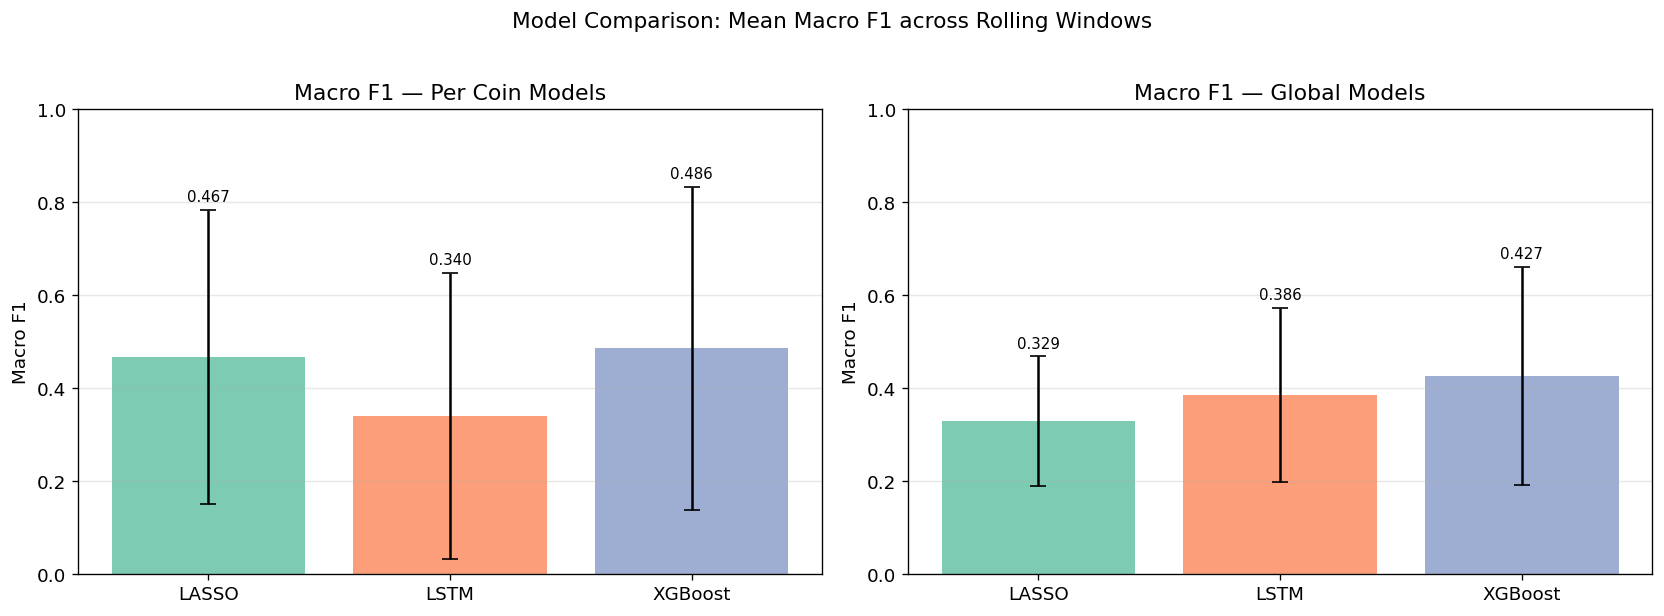

In [29]:
os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scope in zip(axes, ['per_coin', 'global']):
    sub = df_res[df_res['scope'] == scope]
    grp = sub.groupby('model')['macro_f1'].agg(['mean', 'std']).reset_index()
    colors = sns.color_palette('Set2', len(grp))
    bars = ax.bar(grp['model'], grp['mean'], yerr=grp['std'],
                  color=colors, capsize=5, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(f'Macro F1 — {scope.replace("_", " ").title()} Models')
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison: Mean Macro F1 across Rolling Windows', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/macro_f1_comparison.png', bbox_inches='tight')
plt.show()

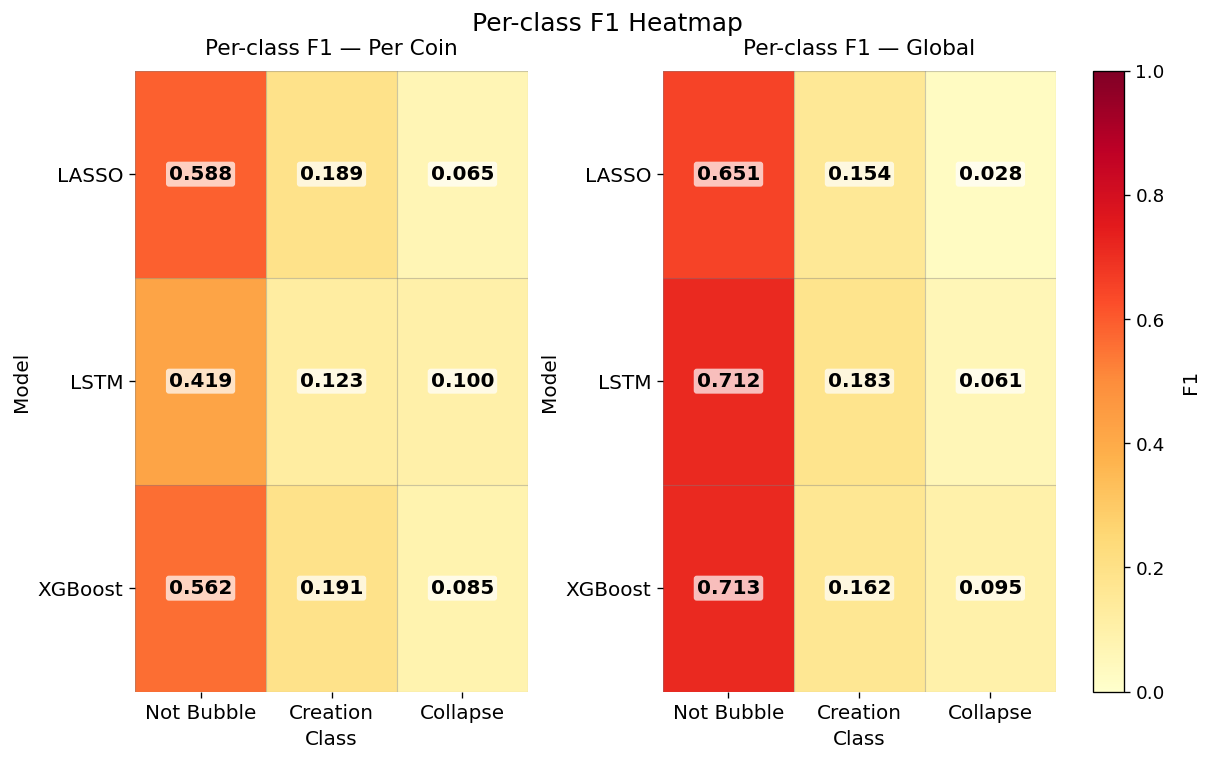

In [59]:
class_metrics = ['f1_not_bubble', 'f1_creation', 'f1_collapse']
fig, axes = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)  # use constrained_layout for better spacing

for ax, scope in zip(axes, ['per_coin', 'global']):
    sub = df_res[df_res['scope'] == scope]
    pivot = (
        sub.groupby('model')[class_metrics].mean()
           .rename(columns={'f1_not_bubble': 'Not Bubble',
                            'f1_creation':   'Creation',
                            'f1_collapse':   'Collapse'})
    )
    data = pivot.values
    im = ax.imshow(data, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', color='black', fontsize=12, fontweight='semibold', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15', alpha=0.7))
    # Set ticks and labels
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_xticklabels(pivot.columns, fontsize=12)
    ax.set_yticklabels(pivot.index, fontsize=12)
    ax.set_title(f'Per-class F1 — {scope.replace("_", " ").title()}', fontsize=13, pad=10)
    ax.set_ylabel('Model', fontsize=12)
    ax.set_xlabel('Class', fontsize=12)
    ax.set_xticks(np.arange(-0.5, data.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, data.shape[0], 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.7, alpha=0.4)
    ax.tick_params(which='minor', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

# Shared colorbar on the right, not above the axes
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.045, pad=0.04, location='right')
cbar.set_label('F1', fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=11)

plt.suptitle('Per-class F1 Heatmap', fontsize=15, y=1.03)
plt.savefig('outputs/per_class_f1_heatmap.png', bbox_inches='tight')
plt.show()

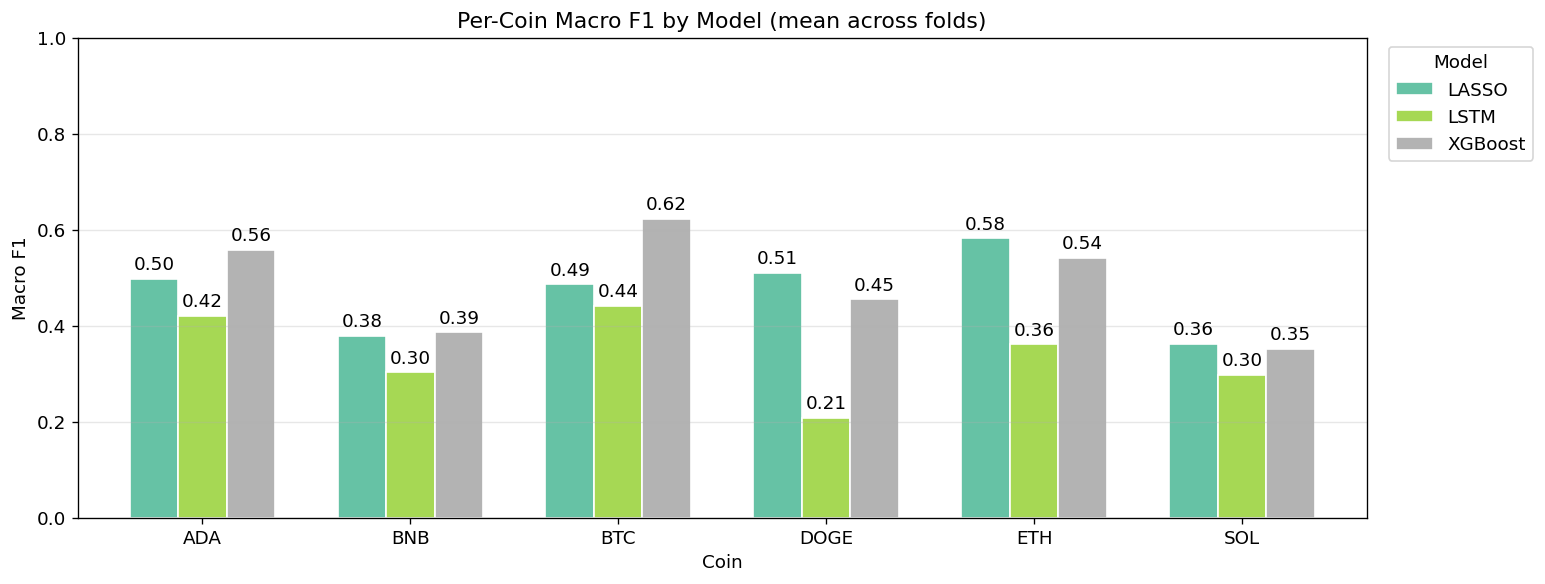

In [12]:
per_coin_df = df_res[df_res['scope'] == 'per_coin']

pivot_coin = (
    per_coin_df.groupby(['coin', 'model'])['macro_f1']
               .mean().unstack('model')
)

ax = pivot_coin.plot(kind='bar', figsize=(13, 5), colormap='Set2',
                     edgecolor='white', width=0.7)

# add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

ax.set_title('Per-Coin Macro F1 by Model (mean across folds)')
ax.set_ylabel('Macro F1')
ax.set_xlabel('Coin')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/per_coin_macro_f1.png', bbox_inches='tight')
plt.show()

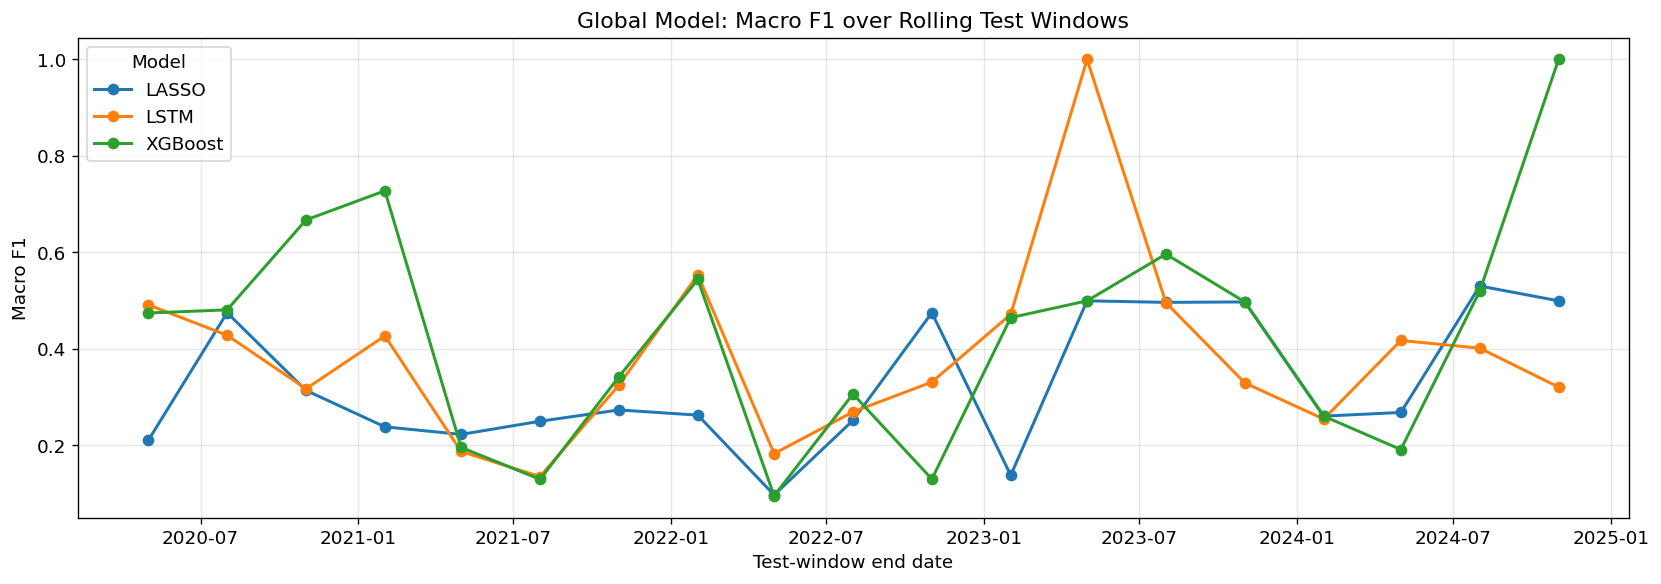

In [32]:
global_df = df_res[df_res['scope'] == 'global'].copy()
global_df['test_end'] = pd.to_datetime(global_df['test_end'])

fig, ax = plt.subplots(figsize=(14, 5))
for model, grp in global_df.groupby('model'):
    grp = grp.sort_values('test_end')
    ax.plot(grp['test_end'], grp['macro_f1'], marker='o', label=model, linewidth=1.8)
ax.set_title('Global Model: Macro F1 over Rolling Test Windows')
ax.set_ylabel('Macro F1')
ax.set_xlabel('Test-window end date')
ax.legend(title='Model')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/global_macro_f1_over_time.png', bbox_inches='tight')
plt.show()

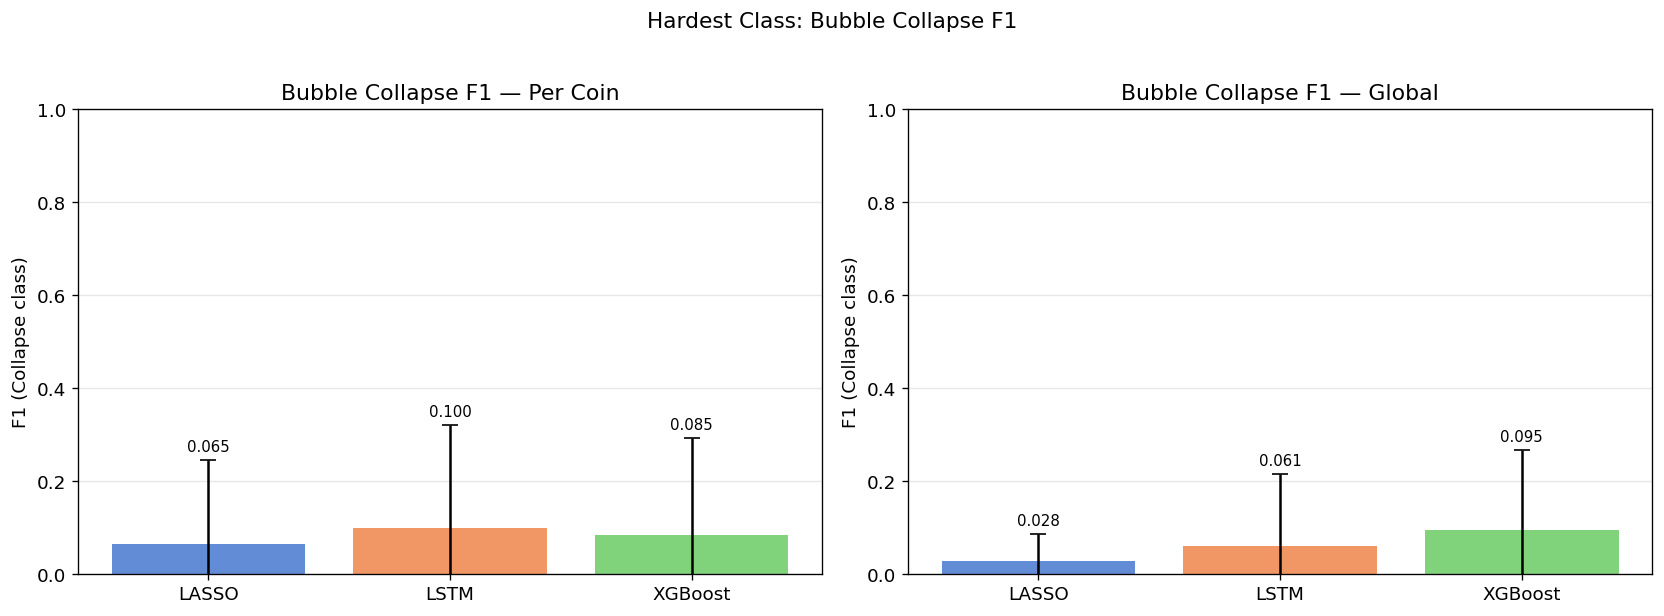

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scope in zip(axes, ['per_coin', 'global']):
    sub = df_res[df_res['scope'] == scope]
    grp = sub.groupby('model')['f1_collapse'].agg(['mean', 'std']).reset_index()
    colors = sns.color_palette('muted', len(grp))
    bars = ax.bar(grp['model'], grp['mean'], yerr=grp['std'],
                  color=colors, capsize=5, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(f'Bubble Collapse F1 — {scope.replace("_", " ").title()}')
    ax.set_ylabel('F1 (Collapse class)')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Hardest Class: Bubble Collapse F1', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/collapse_f1_comparison.png', bbox_inches='tight')
plt.show()

In [34]:
df_res.to_csv('outputs/rolling_window_results.csv', index=False)
summary_mean.to_csv('outputs/model_summary.csv', index=False)
per_coin_summary.to_csv('outputs/per_coin_summary.csv', index=False)
print('Results saved to outputs/')

Results saved to outputs/


## 8. Per-Coin vs Global Comparison

In [35]:
scope_compare = (
    df_res[df_res['scope'] == 'per_coin']
    .groupby('model')['macro_f1'].mean().rename('per_coin').to_frame()
    .join(
        df_res[df_res['scope'] == 'global']
        .groupby('model')['macro_f1'].mean().rename('global')
    )
)
scope_compare['delta (per-global)'] = scope_compare['per_coin'] - scope_compare['global']
print('=== Per-coin vs Global Macro F1 ===')
scope_compare.round(4)

=== Per-coin vs Global Macro F1 ===


,per_coin,global,delta (per-global)
model,,,
LASSO,0.4673,0.3294,0.1379
LSTM,0.3404,0.3862,-0.0458
XGBoost,0.4861,0.4275,0.0587


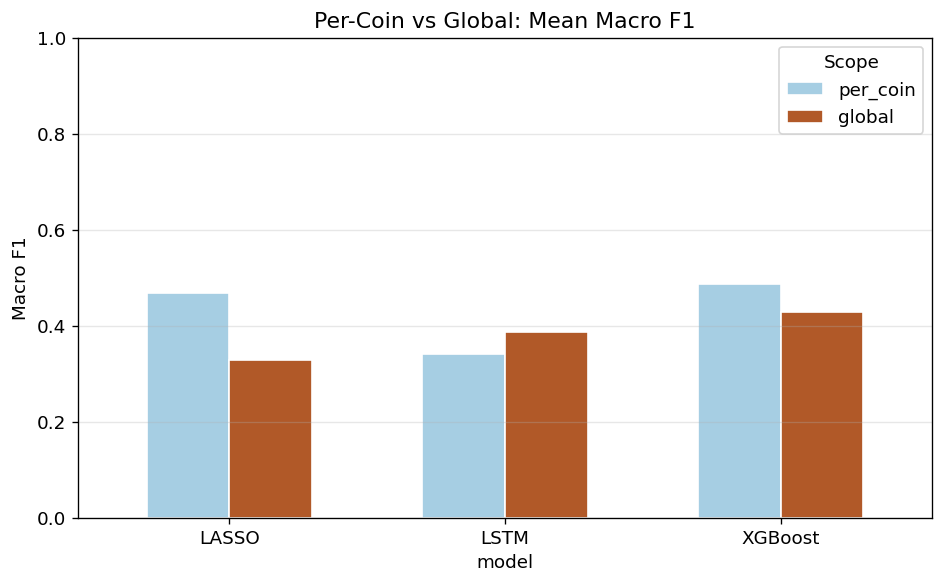

In [36]:
ax = scope_compare[['per_coin', 'global']].plot(
    kind='bar', figsize=(8, 5), colormap='Paired',
    edgecolor='white', width=0.6
)
ax.set_title('Per-Coin vs Global: Mean Macro F1')
ax.set_ylabel('Macro F1')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1)
ax.legend(title='Scope')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/per_coin_vs_global.png', bbox_inches='tight')
plt.show()

## 9. Examine Feature Importance

In [ ]:
#df_res = pd.read_csv("outputs/rolling_window_results.csv")

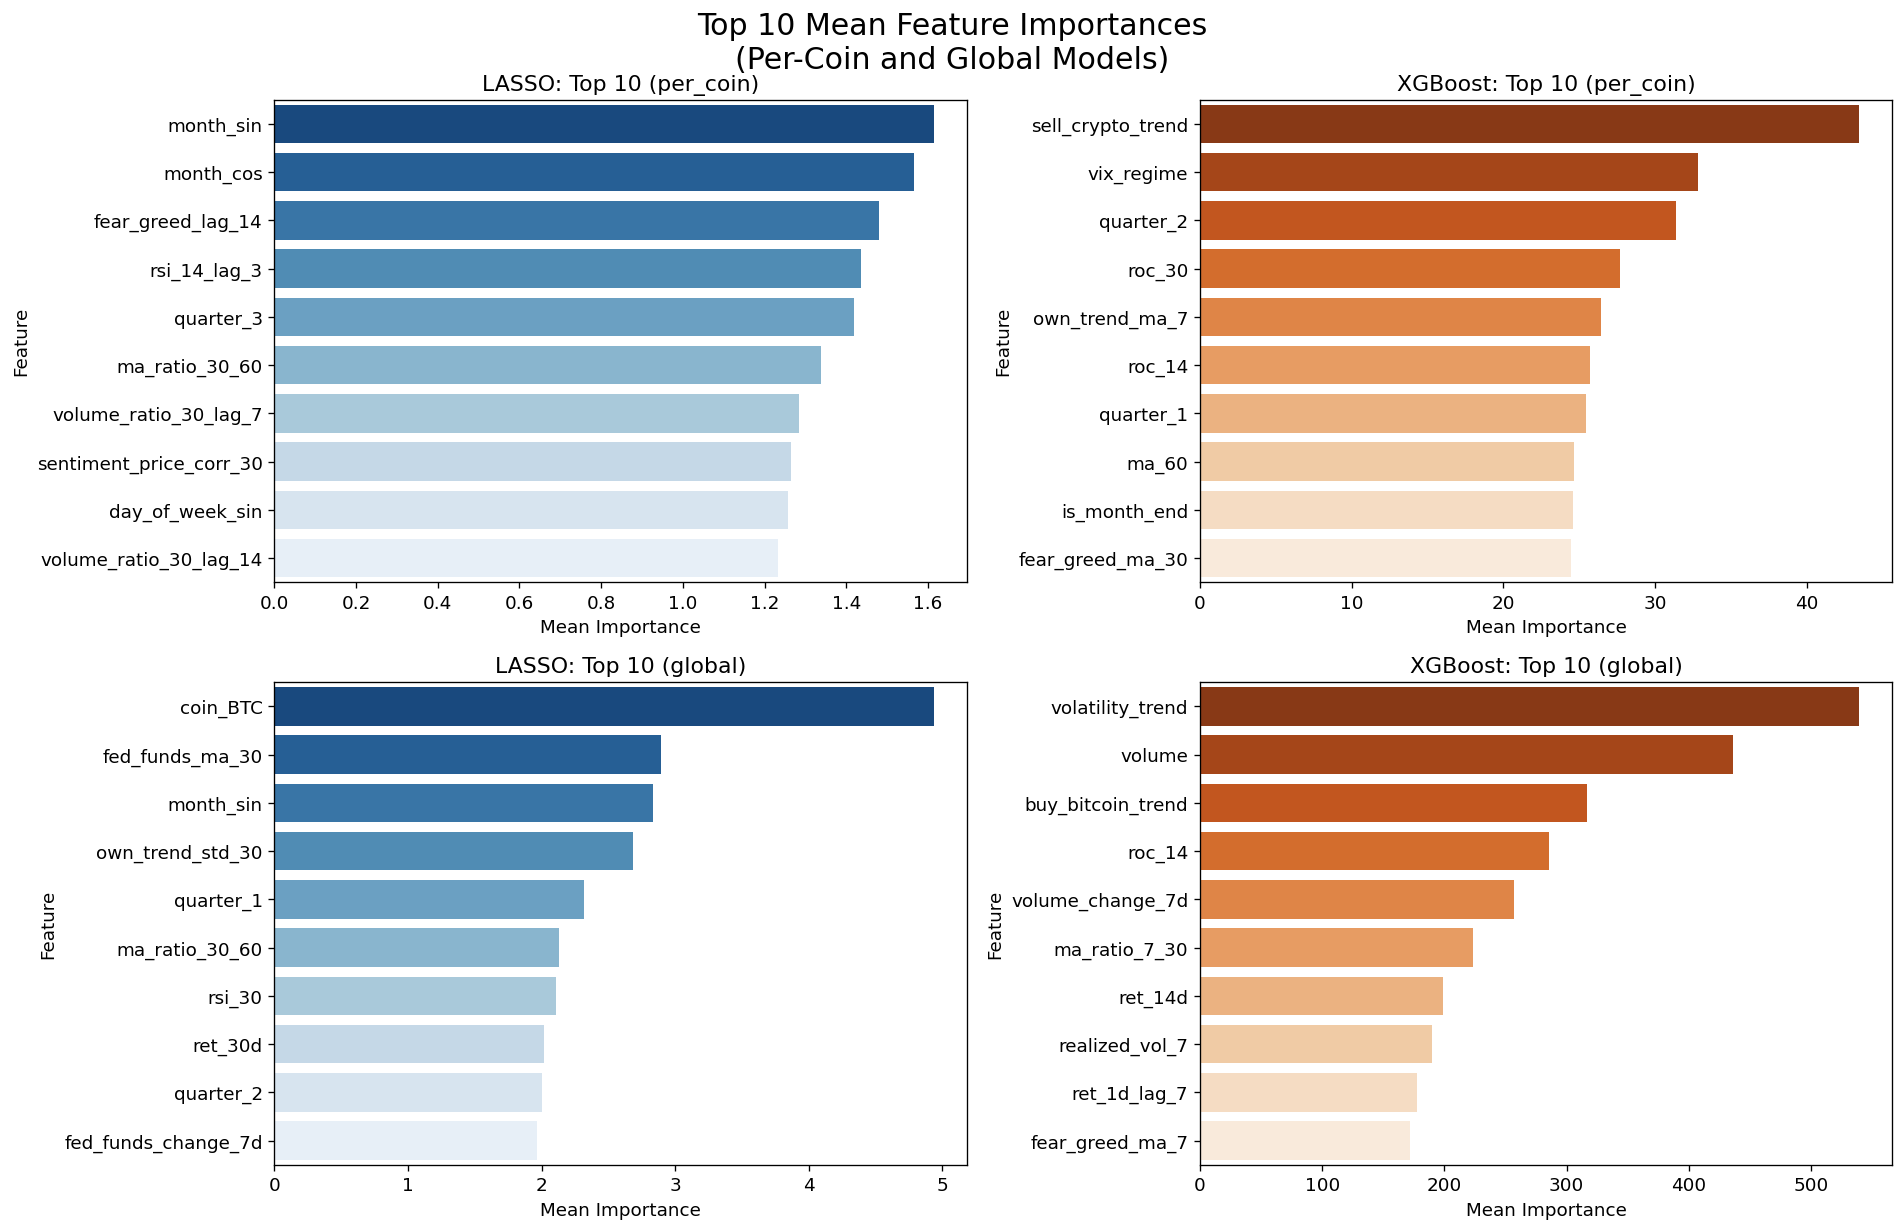

In [ ]:
def plot_top_feature_importances(df_res, feature_names, scope_label, model_label, ax):
    # Helper to map f0, f1, ... to actual feature names
    feature_idx_to_name = {f"f{i}": name for i, name in enumerate(feature_names)}

    def parse_series_str_to_dict(series_str, map_xgb_names=False):
        import re
        if not isinstance(series_str, str):
            return {}
        series_str = re.sub(r"\\ndtype:.*", "", series_str)
        lines = [l for l in series_str.strip().split("\n") if l.strip()]
        fi_dict = {}
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 2:
                key = " ".join(parts[:-1])
                if map_xgb_names and key in feature_idx_to_name:
                    key = feature_idx_to_name[key]
                try:
                    val = float(parts[-1])
                    fi_dict[key] = val
                except Exception:
                    continue
        return fi_dict

    # Select model and scope
    df = df_res[(df_res['model'] == model_label) & (df_res['scope'] == scope_label)].copy()
    map_xgb = (model_label == 'XGBoost')
    fis = df['feature_importance'].map(lambda s: parse_series_str_to_dict(s, map_xgb_names=map_xgb))

    from collections import defaultdict
    def mean_importance(fi_list):
        agg = defaultdict(list)
        for fi in fi_list:
            for k, v in fi.items():
                agg[k].append(v)
        return {k: sum(vs)/len(vs) for k, vs in agg.items() if len(vs) > 0}

    mean_fi = mean_importance(fis)
    top = sorted(mean_fi.items(), key=lambda x: -abs(x[1]))[:10]
    feat, vals = zip(*top) if top else ([],[])

    import seaborn as sns
    sns.barplot(x=vals, y=feat, ax=ax, palette='Blues_r' if model_label=='LASSO' else 'Oranges_r')
    ax.set_title(f'{model_label}: Top 10 ({scope_label})')
    ax.set_xlabel('Mean Importance')
    ax.set_ylabel('Feature')

# Prepare feature names for both per-coin and global 
try:
    feature_names_per_coin = FEATURE_COLS
    feature_names_global = FEATURE_COLS_GLOBAL
except NameError:
    # Try to infer from df_raw
    if 'df_raw' in globals():
        NON_FEATURE_COLS = {
            'date', 'symbol',
            'gsadf_label_90', 'gsadf_label_95', 'label', 'label_lead',
            'fear_greed_classification',
        }
        feature_names_per_coin = [c for c in df_raw.columns if c not in NON_FEATURE_COLS and df_raw[c].dtype != object]
        coin_dummies = pd.get_dummies(df_raw['symbol'], prefix='coin').astype(float)
        feature_names_global = feature_names_per_coin + list(coin_dummies.columns)
    else:
        feature_names_per_coin = []
        feature_names_global = []

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=False)

plot_top_feature_importances(df_res, feature_names_per_coin, 'per_coin', 'LASSO',   axes[0,0])
plot_top_feature_importances(df_res, feature_names_per_coin, 'per_coin', 'XGBoost', axes[0,1])
plot_top_feature_importances(df_res, feature_names_global,  'global',   'LASSO',   axes[1,0])
plot_top_feature_importances(df_res, feature_names_global,  'global',   'XGBoost', axes[1,1])

plt.suptitle('Top 10 Mean Feature Importances\n(Per-Coin and Global Models)', fontsize=18, y=0.93)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('outputs/feature_importance.png', bbox_inches='tight')
plt.show()


In [ ]:
# LASSO: Number of Features Kept/Dropped 
def count_lasso_features(df_res, feature_names, scope_label):
    df = df_res[(df_res['model'] == 'LASSO') & (df_res['scope'] == scope_label)].copy()
    def parse_series_str_to_dict(series_str):
        import re
        if not isinstance(series_str, str):
            return {}
        series_str = re.sub(r"\\ndtype:.*", "", series_str)
        lines = [l for l in series_str.strip().split("\n") if l.strip()]
        fi_dict = {}
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 2:
                key = " ".join(parts[:-1])
                try:
                    val = float(parts[-1])
                    fi_dict[key] = val
                except Exception:
                    continue
        return fi_dict

    fis = df['feature_importance'].map(parse_series_str_to_dict)
    n_features = len(feature_names)

    if scope_label == 'per_coin':
        # Per-coin: group by coin
        results = []
        for coin, group in df.groupby('coin'):
            kept_counts = group['feature_importance'].map(lambda s: sum(np.abs(np.array(list(parse_series_str_to_dict(s).values()))) > 1e-8))
            mean_kept = kept_counts.mean()
            mean_dropped = n_features - mean_kept
            results.append({'coin': coin, 'mean_kept': mean_kept, 'mean_dropped': mean_dropped, 'n_features': n_features})
        lasso_kept_df = pd.DataFrame(results)
        print('--- LASSO Per-Coin: Mean Features Kept/Dropped ---')
        display(lasso_kept_df)
        return lasso_kept_df
    else:
        # Global: aggregate all
        kept_counts = fis.map(lambda d: sum(np.abs(np.array(list(d.values()))) > 1e-8))
        mean_kept = kept_counts.mean()
        mean_dropped = n_features - mean_kept
        print(f'--- LASSO Global: Mean Features Kept/Dropped ---\nMean kept: {mean_kept:.2f} / {n_features} | Mean dropped: {mean_dropped:.2f}')
        return {'mean_kept': mean_kept, 'mean_dropped': mean_dropped, 'n_features': n_features}

# Run for per-coin and global 
lasso_kept_per_coin = count_lasso_features(df_res, feature_names_per_coin, 'per_coin')
lasso_kept_global = count_lasso_features(df_res, feature_names_global, 'global')

--- LASSO Per-Coin: Mean Features Kept/Dropped ---


,coin,mean_kept,mean_dropped,n_features
0,ADA,4.7857,128.2143,133
1,BNB,5.0556,127.9444,133
2,BTC,5.1333,127.8667,133
3,DOGE,4.9231,128.0769,133
4,ETH,4.5000,128.5000,133
5,SOL,5.0000,128.0000,133


--- LASSO Global: Mean Features Kept/Dropped ---
Mean kept: 5.53 / 139 | Mean dropped: 133.47


## 10. Bubble timeline plot

Using model=XGBoost, scope=per_coin


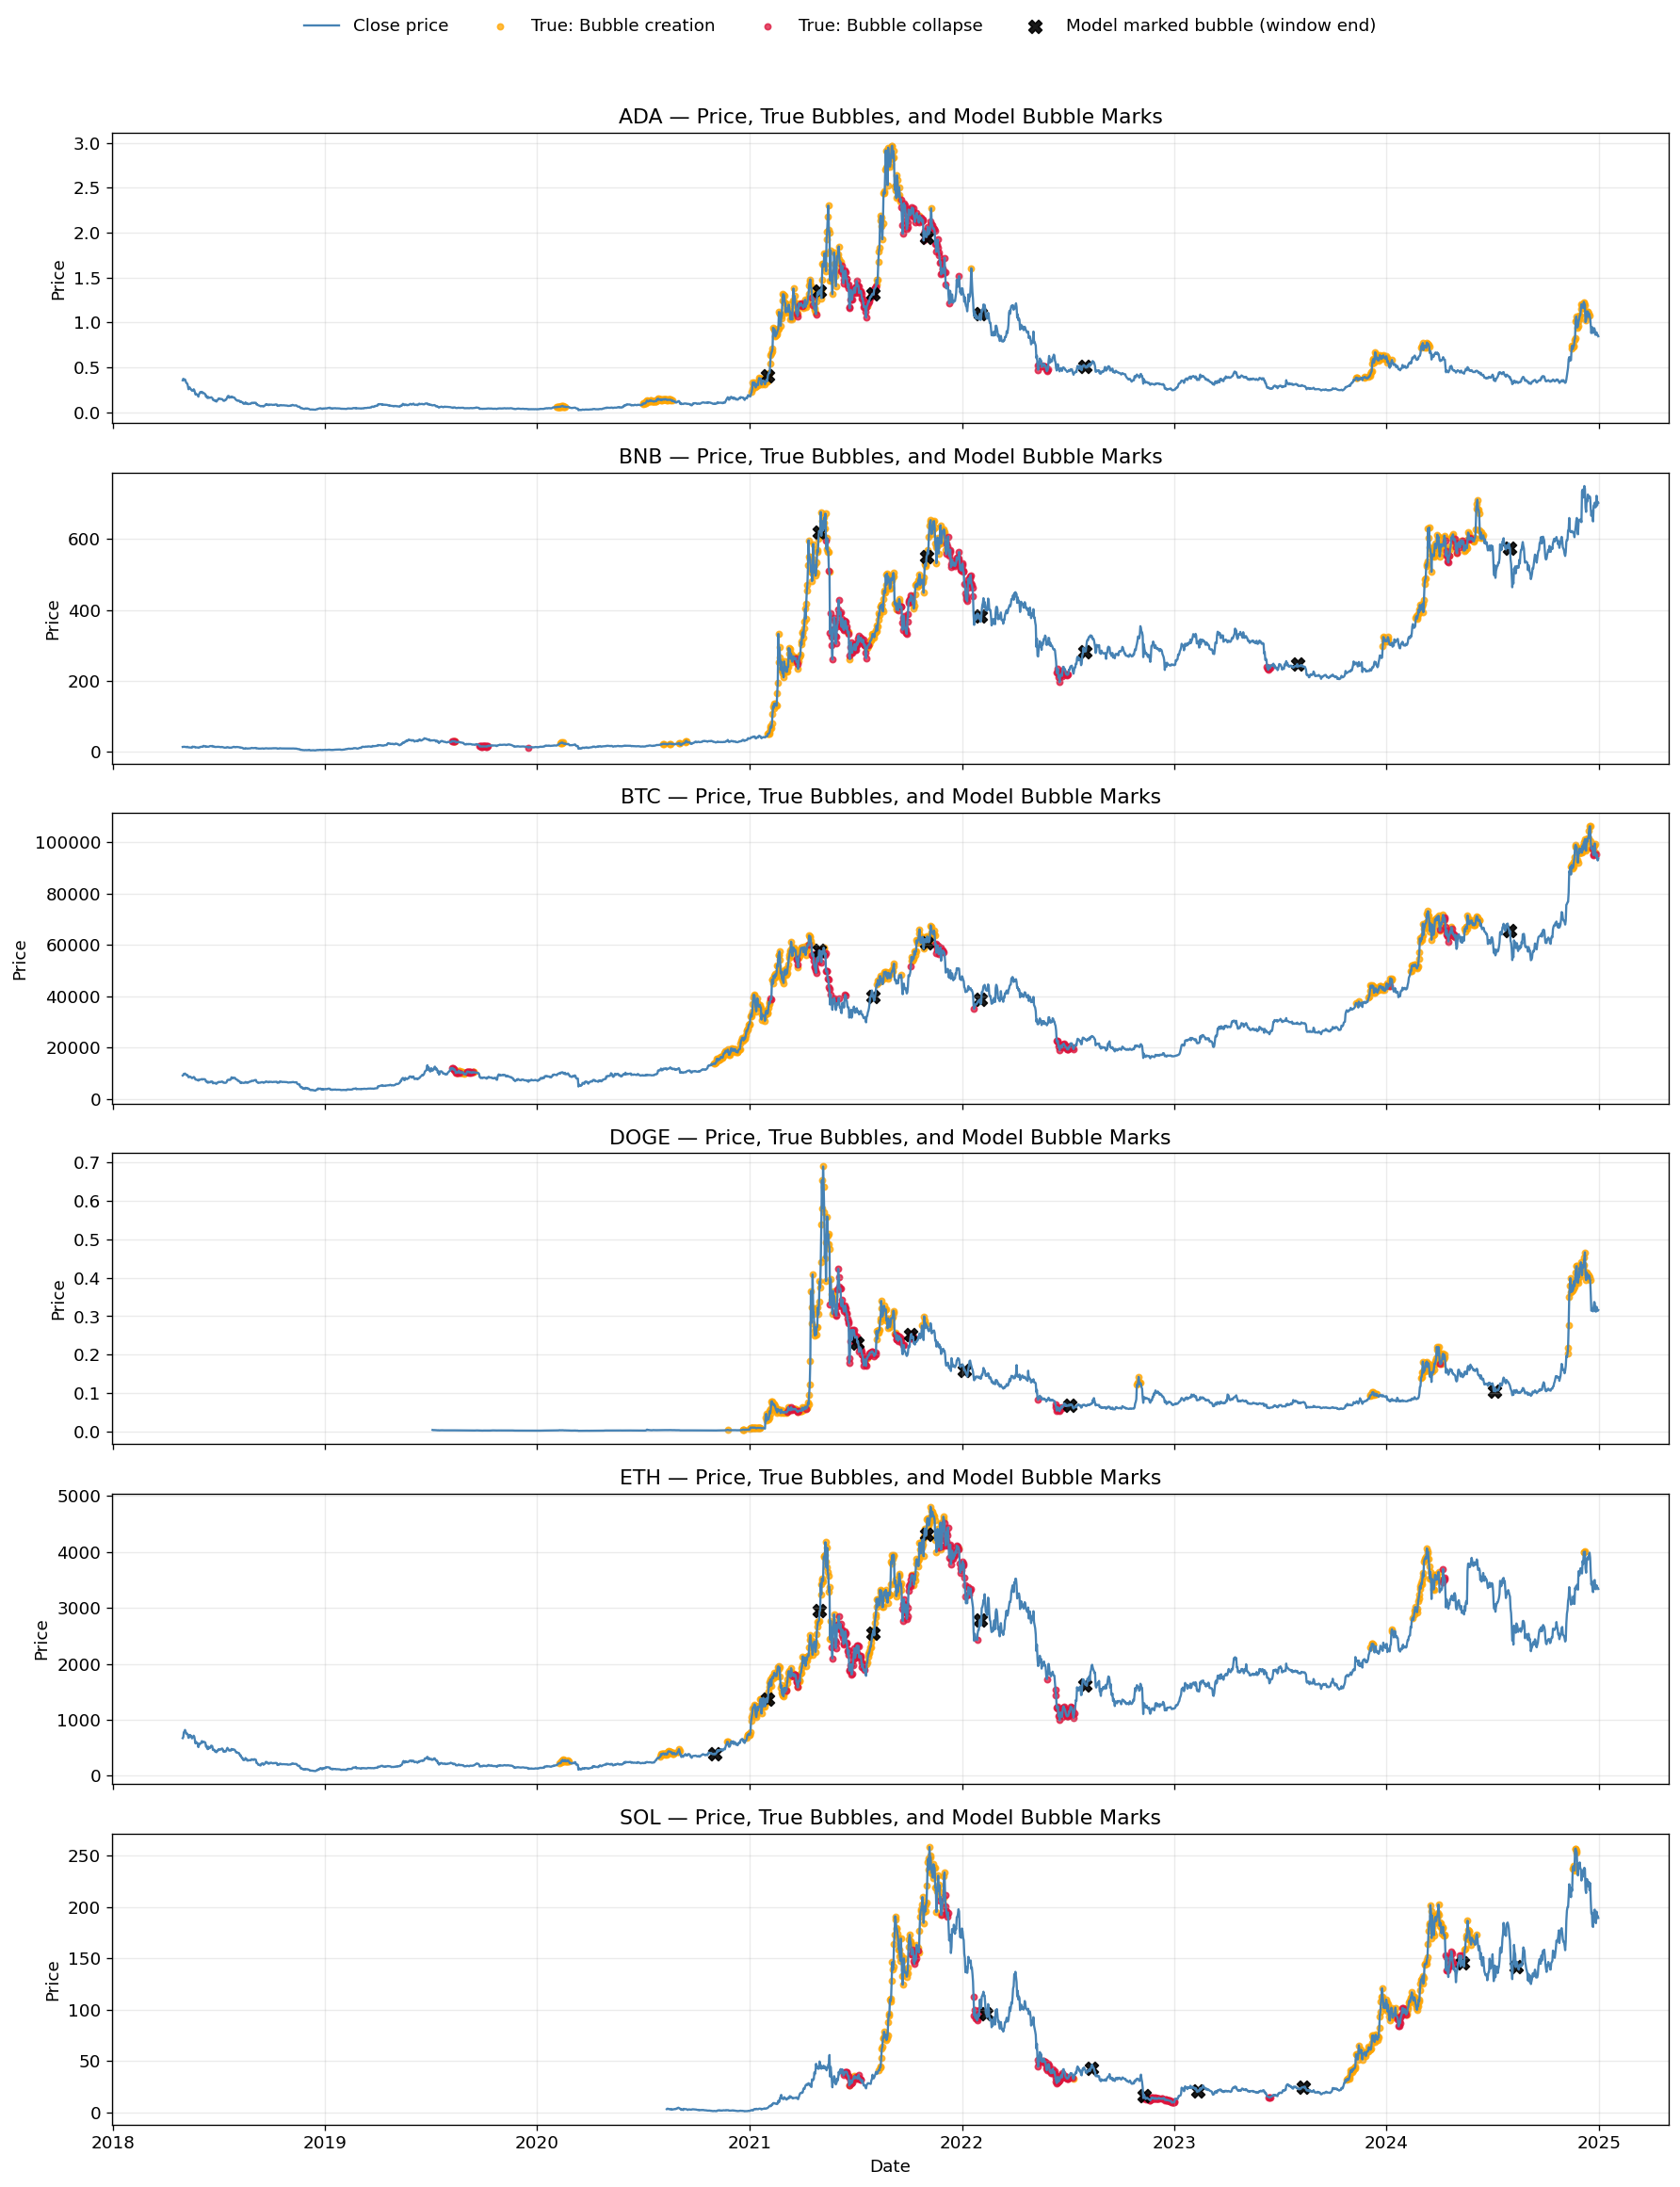

In [ ]:
# - Price over time
# - True bubble regimes from labels
# - Model "bubble mark" proxy from rolling-window results  (window test_end where f1_creation>0 or f1_collapse>0)
best_model = summary_mean.iloc[0]['model']
best_scope = summary_mean.iloc[0]['scope']
print(f'Using model={best_model}, scope={best_scope}')

# choose bubble label column for ground truth visualization
bubble_col = 'label' if 'label' in df_raw.columns else TARGET

def price_at_or_before(df_coin, dt):
    s = df_coin[df_coin['date'] <= dt]
    if len(s) == 0:
        return np.nan
    return s.iloc[-1]['close']

fig, axes = plt.subplots(len(COINS), 1, figsize=(15, 3.2 * len(COINS)), sharex=True)
if len(COINS) == 1:
    axes = [axes]

for ax, coin in zip(axes, COINS):
    d = df_raw[df_raw['symbol'] == coin].sort_values('date').copy()

    # price line
    ax.plot(d['date'], d['close'], color='steelblue', linewidth=1.4, label='Close price')

    # true bubbles (creation / collapse)
    if bubble_col in d.columns:
        creation = d[d[bubble_col] == 1]
        collapse = d[d[bubble_col] == 2]
        ax.scatter(creation['date'], creation['close'], s=14, color='orange', alpha=0.75, label='True: Bubble creation')
        ax.scatter(collapse['date'], collapse['close'], s=14, color='crimson', alpha=0.75, label='True: Bubble collapse')

    # model marks from rolling-window results where f1_creation or f1_collapse > 0 
    r = df_res[(df_res['model'] == best_model) & (df_res['scope'] == best_scope)].copy()
    if best_scope == 'per_coin':
        r = r[r['coin'] == coin]

    if not r.empty:
        r['test_end'] = pd.to_datetime(r['test_end'])
        r_mark = r[(r['f1_creation'] > 0) | (r['f1_collapse'] > 0)].copy()

        mark_dates = r_mark['test_end'].sort_values().unique()
        mark_prices = [price_at_or_before(d, dt) for dt in mark_dates]

        ax.scatter(
            mark_dates, mark_prices,
            marker='X', s=70, color='black', alpha=0.9,
            label='Model marked bubble (window end)'
        )

    ax.set_title(f'{coin} — Price, True Bubbles, and Model Bubble Marks')
    ax.set_ylabel('Price')
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.01))
plt.xlabel('Date')
plt.tight_layout(rect=[0, 0, 1, 0.97])

os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/price_bubbles_model_marks.png', bbox_inches='tight')
plt.show()